In [1]:
import data

import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.nn import functional as F
import albumentations as A
import numpy as np
import cv2
from PIL import Image

In [2]:
class Decoder(nn.Module):
    def __init__(self, in_size: int, skip_size: int, out_size: int):
        super().__init__()

        self.upsample = nn.ConvTranspose2d(
            in_size, out_size, kernel_size=2, stride=2)

        self.conv = nn.Sequential(
            nn.Conv2d(out_size + skip_size, out_size, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_size, out_size, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        up = self.upsample(x)

        # handles odd input dimensions
        if up.shape != skip.shape:
            up = F.interpolate(
                up, size=skip.shape[-2:], mode="bilinear",
                align_corners=False)
        both = torch.cat([skip, up], dim=1)
        return self.conv(both)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.enc2 = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.enc3 = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.bottleneck = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.dec3 = Decoder(256, 128, 128)
        self.dec2 = Decoder(128, 64, 64)
        self.dec1 = Decoder(64, 32, 32)

        self.output = nn.Sequential(
            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        b = self.bottleneck(e3)
        d3 = self.dec3(b, e3)
        d2 = self.dec2(d3, e2)
        d1 = self.dec1(d2, e1)
        return self.output(d1)

In [3]:
model = UNet()
model.eval()
device = torch.device("cpu")
weights = torch.load("models/02-unet-larger_best.model", map_location=device, weights_only=True)
model.load_state_dict(weights)

<All keys matched successfully>

In [4]:
noise_pipeline = A.Compose([
    A.GaussNoise(p=1.0),
])

norm_pipeline = A.Compose([
    A.Normalize(normalization="min_max", max_pixel_value=255),
])

images_path = data.get_images_path()
samples = data.get_sorted_samples(images_path)
train_samples, val_samples, test_samples = data.split_train_val_test(
    samples, data.TRAIN_TEST_DEFAULT_SEED, shuffle=True)
train_samples.extend(test_samples)

In [5]:
def apply_denoiser(noise: A.Compose, model: UNet, img_path: str) -> Image:
    img = cv2.imread(img_path, cv2.IMREAD_COLOR_RGB)
    noisy_img = noise_pipeline(image=img)['image']
    norm_img = norm_pipeline(image=noisy_img)['image']
    img_t = torch.tensor(norm_img.transpose((2, 0, 1)))
    out_t = model(img_t.unsqueeze(0))
    out_np = out_t[0].detach().numpy()
    out_img = (out_np.transpose((1, 2, 0)) * 255).astype(np.uint8)
    if img.shape != out_img.shape:
        pad_sizes = (
            (0, img.shape[0] - out_img.shape[0]),
            (0, img.shape[1] - out_img.shape[1]),
            (0, 0),
        )
        out_img = np.pad(out_img, pad_sizes)
    stacked_img = np.hstack([img, noisy_img, out_img])
    return Image.fromarray(stacked_img)

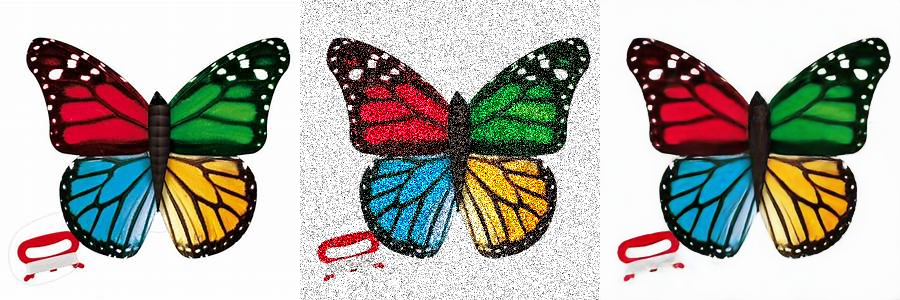

In [8]:
img = apply_denoiser(noise_pipeline, model, val_samples[0][0])
img.save("butterfly-unet.png")
img

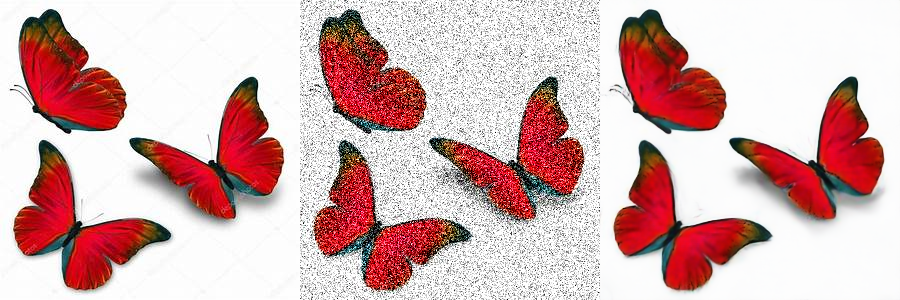

In [7]:
img = apply_denoiser(noise_pipeline, model, val_samples[11][0])
img

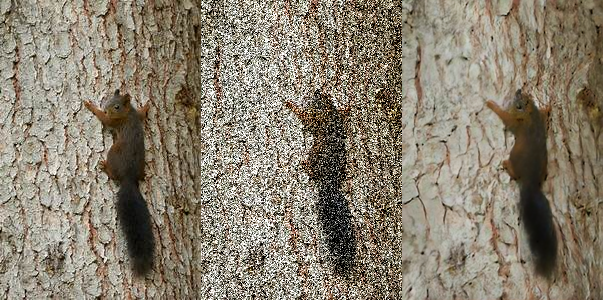

In [9]:
img = apply_denoiser(noise_pipeline, model, test_samples[3][0])
img.save("squirrel-unet.png")
img

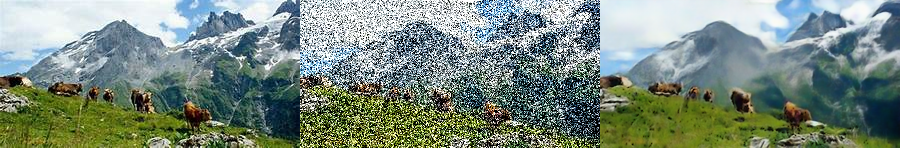

In [11]:
apply_denoiser(noise_pipeline, model, test_samples[4][0])

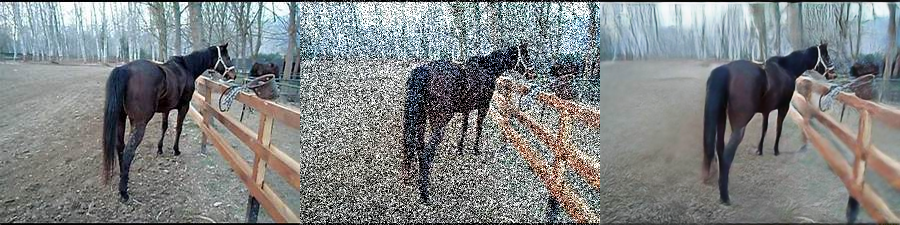

In [10]:
img = apply_denoiser(noise_pipeline, model, train_samples[3][0])
img.save("horse-unet.png")
img

In [12]:
def get_denoised(noise: A.Compose, model: UNet, img_path: str) -> Image:
    img = cv2.imread(img_path, cv2.IMREAD_COLOR_RGB)
    noisy_img = noise_pipeline(image=img)['image']
    norm_img = norm_pipeline(image=noisy_img)['image']
    img_t = torch.tensor(norm_img.transpose((2, 0, 1)))
    out_t = model(img_t.unsqueeze(0))
    out_np = out_t[0].detach().numpy()
    out_img = (out_np.transpose((1, 2, 0)) * 255).astype(np.uint8)
    return Image.fromarray(out_img)

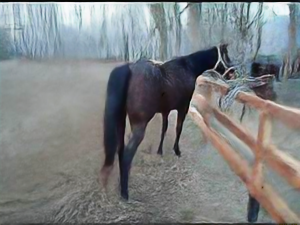

In [13]:
get_denoised(noise_pipeline, model, train_samples[3][0])

In [14]:
for input_name, out_name in (
    (val_samples[0][0], "butterfly-unet-only.png"),
    (test_samples[3][0], "squirrel-unet-only.png"),
    (train_samples[3][0], "horse-unet-only.png")
):
    img = get_denoised(noise_pipeline, model, input_name)
    img.save(out_name)